In [ ]:
import matplotlib.pyplot as plt
from price.shared import get_prices_by_ram_type
from price.source.enterkomputer import get_from_date
from datetime import date
from price.source.generic import get_from_json

['DDR4-3200 2x8GB', 'DDR4-3200 2x16GB', 'DDR4-3200 2x32GB', 'DDR4-3600 2x8GB', 'DDR4-3600 2x16GB', 'DDR4-3600 2x32GB', 'DDR5-4800 2x16GB', 'DDR5-5200 2x8GB', 'DDR5-5200 2x16GB', 'DDR5-5200 2x32GB', 'DDR5-5600 2x8GB', 'DDR5-5600 2x16GB', 'DDR5-5600 2x32GB', 'DDR5-6000 2x8GB', 'DDR5-6000 2x16GB', 'DDR5-6000 2x32GB'] [[2.695, 2.647, 2.193915, 2.447175, 2.447175, 2.246175, 2.197935, 2.36577, 2.36577, 2.50245, 1.939, 1.999, 1.999, 2.599, 2.599, 2.499, 2.49, 2.07, 2.43, 2.31, 2.57, 2.42, 2.47, 2.31, 2.33, 2.315, 2.42, 2.23, 1.955, 2.23, 2.23, 2.45, 1.43, 2.55, 2.45, 2.55, 2.39, 2.38], [5.245, 4.905405, 4.905405, 3.9195, 4.79184, 4.79184, 4.859175, 4.360695, 3.099, 4.849, 4.849, 4.919, 4.88, 4.85, 4.239, 4.82, 4.239, 4.95, 4.14, 4.8, 4.79, 4.79, 4.09, 3.03, 3.999, 4.1, 4.1, 3.999, 4.22, 4.89], [10.29, 9.54951, 7.819, 7.819, 9.769, 9.69, 9.85, 7.75, 7.75], [2.575815, 2.575815, 2.581845, 2.459, 2.099, 2.099, 2.679, 2.679, 2.395, 2.65, 2.65, 2.7, 2.52, 2.35, 2.55, 2.35, 2.73, 3.72, 2.13, 2.13, 2

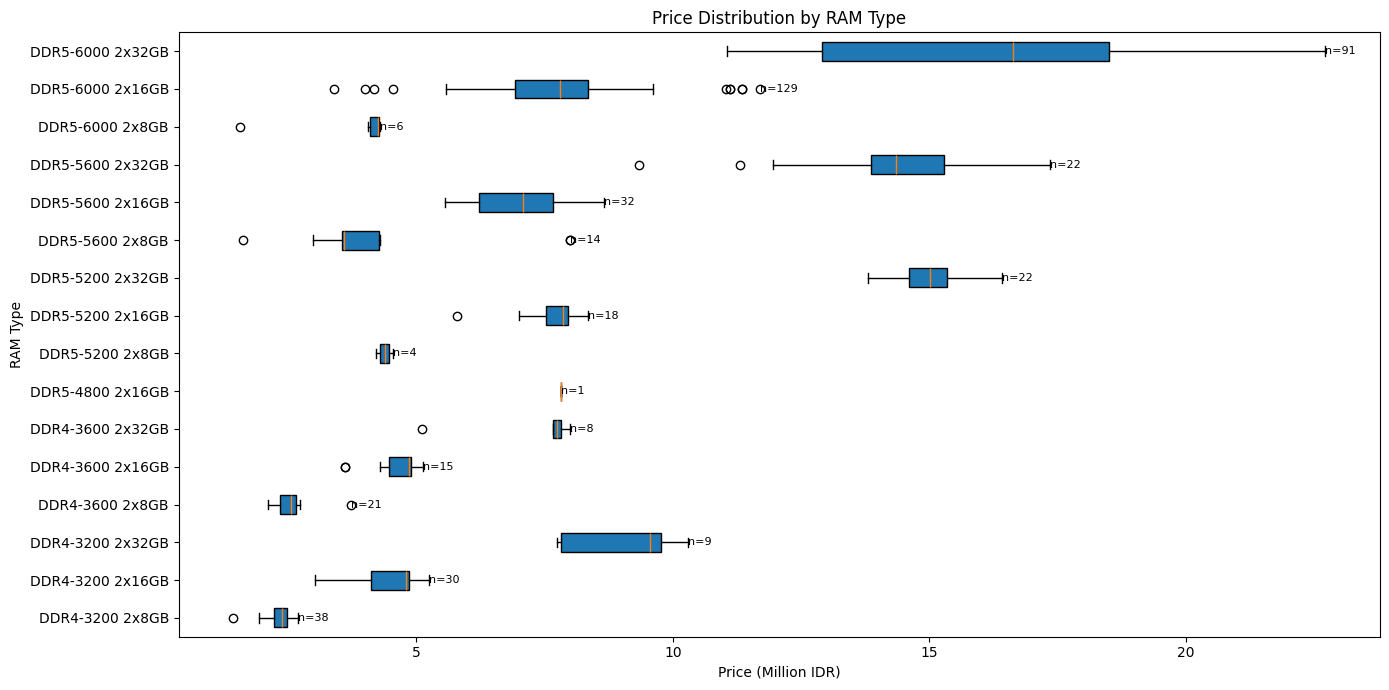

In [3]:
from price.shared import ProductCategory
import re

prices_by_type = get_prices_by_ram_type(
    [
        *list(get_from_json("data/teamgroup.json", ProductCategory.RAM)),
        *list(get_from_json("data/corsair.json", ProductCategory.RAM)),
        *list(get_from_json("data/kingston.json", ProductCategory.RAM)),
        *list(get_from_json("data/expertkomputer.json", ProductCategory.RAM)),
        *list(get_from_json("data/nanokomputer.json", ProductCategory.RAM)),
        *list(get_from_date(date(2026, 2, 24), ProductCategory.RAM)),
    ])

def ram_sort_key(t):
    m = re.match(r'DDR(\d)-(\d+) (\d+)x(\d+)GB', t.value)
    gen, speed, count, size = int(m[1]), int(m[2]), int(m[3]), int(m[4])
    total = count * size
    return (gen, speed, total)

sorted_types = sorted(prices_by_type.keys(), key=ram_sort_key)
labels = [t.value for t in sorted_types]
box_data = [prices_by_type[t] for t in sorted_types]

box_data = [[p / 1e6 for p in prices] for prices in box_data]

print(labels, box_data)
fig, ax = plt.subplots(figsize=(14, 7))
ax.boxplot(box_data, tick_labels=labels, vert=False, patch_artist=True)
ax.set_ylabel("RAM Type")
ax.set_xlabel("Price (Million IDR)")
ax.set_title("Price Distribution by RAM Type")

for i, t in enumerate(sorted_types):
    ax.annotate(
        f"n={len(prices_by_type[t])}",
        xy=(max(box_data[i]), i + 1),
        ha="left",
        va="center",
        fontsize=8,
    )

plt.tight_layout()
plt.show()